# Evaluation Metrics Overview

This notebook consumes the precomputed summary files in `scripts/opera_log/summary_jsonl` to visualize CHAIR and POPE evaluation metrics across decoding configurations.

In [ ]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Set the style for all visualizations
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
	"figure.figsize": (10, 6),
	"axes.titleweight": "bold",
	"font.size": 12,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10
})

In [ ]:
def resolve_paths() -> tuple[Path, Path]:
    start = Path.cwd().resolve()
    for path in [start, *start.parents]:
        summary_dir = path / "opera_log" / "summary_jsonl"
        if summary_dir.exists():
            return path, summary_dir
    raise FileNotFoundError("Cannot locate summary files from current working directory.")


def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"Summary file not found: {path}")
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return pd.DataFrame(records)


def format_decoding_label(method: str, variant: str) -> str:
    if not variant or variant in {"baseline", "default"}:
        return method
    pretty_variant = variant.replace("-", " ")
    return f"{method} ({pretty_variant})"


def scale_metric_coumns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype(float) * 100
    return df


def load_chair_summary(summary_root: Path) -> pd.DataFrame:
    df = load_jsonl(summary_root / "chair_summary.jsonl")
    if df.empty:
        return df
    df["variant"] = df["variant"].fillna("baseline")
    df["metric_variant"] = df["metric_variant"].fillna("default")
    df["decoding"] = df.apply(lambda row: format_decoding_label(row["method"], row["variant"]), axis=1)
    df = scale_metric_columns(df, ["CHAIRs", "CHAIRi", "Recall", "Len"])
    return df


def load_pope_summary(summary_root: Path) -> pd.DataFrame:
    df = load_jsonl(summary_root / "pope_summary.jsonl")
    if df.empty:
        return df
    df["variant"] = df["variant"].fillna("baseline")
    df["metric_variant"] = df["metric_variant"].fillna("default")
    df["decoding"] = df.apply(lambda row: format_decoding_label(row["method"], row["variant"]), axis=1)
    df = scale_metric_columns(df, ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"])
    return df



In [3]:
REPO_ROOT, SUMMARY_ROOT = resolve_paths()

print(f"Repository root: {REPO_ROOT}")
print(f"Summary directory: {SUMMARY_ROOT}")

chair_df = load_chair_summary(SUMMARY_ROOT)
pope_df = load_pope_summary(SUMMARY_ROOT)

print(f"Loaded {len(chair_df)} CHAIR metric entries from {SUMMARY_ROOT / 'chair_summary.jsonl'}")
print(f"Loaded {len(pope_df)} POPE metric entries from {SUMMARY_ROOT / 'pope_summary.jsonl'}")

display(chair_df.head())
display(pope_df.head())


Repository root: /home/li0007xu/mayflower/Efficient-HA
Summary directory: /home/li0007xu/mayflower/Efficient-HA/opera_log/summary_jsonl
Loaded 31 CHAIR metric entries from /home/li0007xu/mayflower/Efficient-HA/opera_log/summary_jsonl/chair_summary.jsonl
Loaded 57 POPE metric entries from /home/li0007xu/mayflower/Efficient-HA/opera_log/summary_jsonl/pope_summary.jsonl


,dataset,provider,model,method,variant,metric_variant,source,CHAIRs,CHAIRi,Recall,Len,decoding
0,chair,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,default,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,13.772455,5.459057,44.791667,61.151697,beam
1,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,alpha-schedule,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,12.000000,5.112474,44.227006,61.186000,deco (10 layers)
2,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,default,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,12.200000,4.976775,45.466406,61.258000,deco (10 layers)
3,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,improved,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,9.800000,3.853955,43.574690,60.422000,deco (10 layers)
4,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,improved,opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3...,11.800000,4.732928,44.553164,61.244000,deco (8 layers)


,dataset,provider,model,pope_type,type_alias,method,variant,metric_variant,source,accuracy,...,fn,tn,samples,f1_macro,precision_macro,recall_macro,f1_weighted,precision_weighted,recall_weighted,decoding
0,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,adv,deco,10-layers,improved,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,83.733333,...,330,1170,3000,0.836797,0.841828,0.837333,83.679687,84.182784,83.733333,deco (10 layers)
1,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,adv,greedy,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,83.066667,...,348,1152,3000,0.829999,0.835944,0.830667,82.999905,83.594382,83.066667,greedy
2,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,pop,deco,10-layers,improved,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,87.600000,...,214,1286,3000,0.875957,0.876525,0.876000,87.595678,87.652479,87.600000,deco (10 layers)
3,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,pop,greedy,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,87.266667,...,222,1278,3000,0.872612,0.873304,0.872667,87.261226,87.330444,87.266667,greedy
4,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,rand,beam,baseline,default,opera_log/pope_eval_results/Qwen/Qwen2.5-VL-3B...,92.096220,...,75,1335,2910,0.920961,0.921578,0.921738,92.096967,92.237003,92.096220,beam


In [4]:
chair_overview = (
    chair_df[
        [
            "dataset",
            "provider",
            "model",
            "method",
            "variant",
            "metric_variant",
            "CHAIRs",
            "CHAIRi",
        ]
    ]
    .sort_values(["provider", "model", "method", "variant", "metric_variant"])
    .reset_index(drop=True)
)

display(chair_overview)


,dataset,provider,model,method,variant,metric_variant,CHAIRs,CHAIRi
0,chair,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,default,13.772455,5.459057
1,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,alpha-schedule,12.000000,5.112474
2,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,default,12.200000,4.976775
3,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,improved,9.800000,3.853955
4,chair,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,improved,11.800000,4.732928
5,chair,Qwen,Qwen2.5-VL-3B-Instruct,dola,10-layers,default,13.745020,6.123869
6,chair,Qwen,Qwen2.5-VL-3B-Instruct,greedy,baseline,default,12.794268,5.451448
7,chair,google,gemma-3-4b-it,beam,baseline,default,4.800000,2.962085
8,chair,google,gemma-3-4b-it,deco,10-layers,default,5.088063,3.241297
9,chair,google,gemma-3-4b-it,deco,10-layers,improved,5.000000,3.329223


In [5]:
pope_overview = (
    pope_df[
        [
            "dataset",
            "provider",
            "model",
            "pope_type",
            "method",
            "variant",
            "metric_variant",
            "accuracy",
            "f1_weighted",
            "precision_weighted",
            "recall_weighted",
        ]
    ]
    .sort_values(["provider", "model", "pope_type", "method", "variant", "metric_variant"])
    .reset_index(drop=True)
)

display(pope_overview)


,dataset,provider,model,pope_type,method,variant,metric_variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,deco,10-layers,improved,83.733333,83.679687,84.182784,83.733333
1,pope,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,greedy,baseline,default,83.066667,82.999905,83.594382,83.066667
2,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,deco,10-layers,improved,87.600000,87.595678,87.652479,87.600000
3,pope,Qwen,Qwen2.5-VL-3B-Instruct,popular,greedy,baseline,default,87.266667,87.261226,87.330444,87.266667
4,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,beam,baseline,default,92.096220,92.096967,92.237003,92.096220
5,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,deco,10-layers,improved,92.199313,92.199395,92.372120,92.199313
6,pope,Qwen,Qwen2.5-VL-3B-Instruct,random,greedy,baseline,default,91.993127,91.993041,92.173056,91.993127
7,pope,google,gemma-3-4b-it,adversarial,beam,baseline,default,79.500000,79.384035,80.179028,79.500000
8,pope,google,gemma-3-4b-it,adversarial,deco,10-layers,improved,79.433333,79.308520,80.161073,79.433333
9,pope,google,gemma-3-4b-it,adversarial,dola,10-layers,default,78.766667,78.589365,79.752178,78.766667


In [10]:
chair_table = (
    chair_df
    .sort_values(["metric_variant", "provider", "model", "method", "variant"])    [["metric_variant", "provider", "model", "method", "variant", "CHAIRs", "CHAIRi"]]
)

def display_chair_tables(df: pd.DataFrame):
    for metric_variant, subset in df.groupby("metric_variant"):
        styled = (
            subset.drop(columns="metric_variant")
            .reset_index(drop=True)
            .style
            .format({"CHAIRs": "{:.1f}", "CHAIRi": "{:.1f}"})
            .set_caption(f"Table 1.{metric_variant}: CHAIR metrics — metric_variant = {metric_variant}")
        )
        display(styled)


display_chair_tables(chair_table)


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,12.0,5.1
1,google,gemma-3n-E4B-it,deco,10-layers,14.0,7.0
2,llava-hf,llava-1.5-7b-hf,deco,10-layers,22.8,7.1


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,beam,baseline,13.8,5.5
1,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,12.2,5.0
2,Qwen,Qwen2.5-VL-3B-Instruct,dola,10-layers,13.7,6.1
3,Qwen,Qwen2.5-VL-3B-Instruct,greedy,baseline,12.8,5.5
4,google,gemma-3-4b-it,beam,baseline,4.8,3.0
5,google,gemma-3-4b-it,deco,10-layers,5.1,3.2
6,google,gemma-3-4b-it,dola,10-layers,5.2,3.6
7,google,gemma-3-4b-it,greedy,baseline,4.8,2.9
8,google,gemma-3n-E2B-it,beam,baseline,14.0,6.9
9,google,gemma-3n-E2B-it,deco,10-layers,13.2,6.3


,provider,model,method,variant,CHAIRs,CHAIRi
0,Qwen,Qwen2.5-VL-3B-Instruct,deco,10-layers,9.8,3.9
1,Qwen,Qwen2.5-VL-3B-Instruct,deco,8-layers,11.8,4.7
2,google,gemma-3-4b-it,deco,10-layers,5.0,3.3
3,google,gemma-3n-E2B-it,deco,10-layers,12.0,6.3
4,google,gemma-3n-E4B-it,deco,10-layers,12.4,6.6
5,google,gemma-3n-E4B-it,deco,8-layers,12.4,6.3
6,llava-hf,llava-1.5-7b-hf,deco,8-layers,22.6,7.1


/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


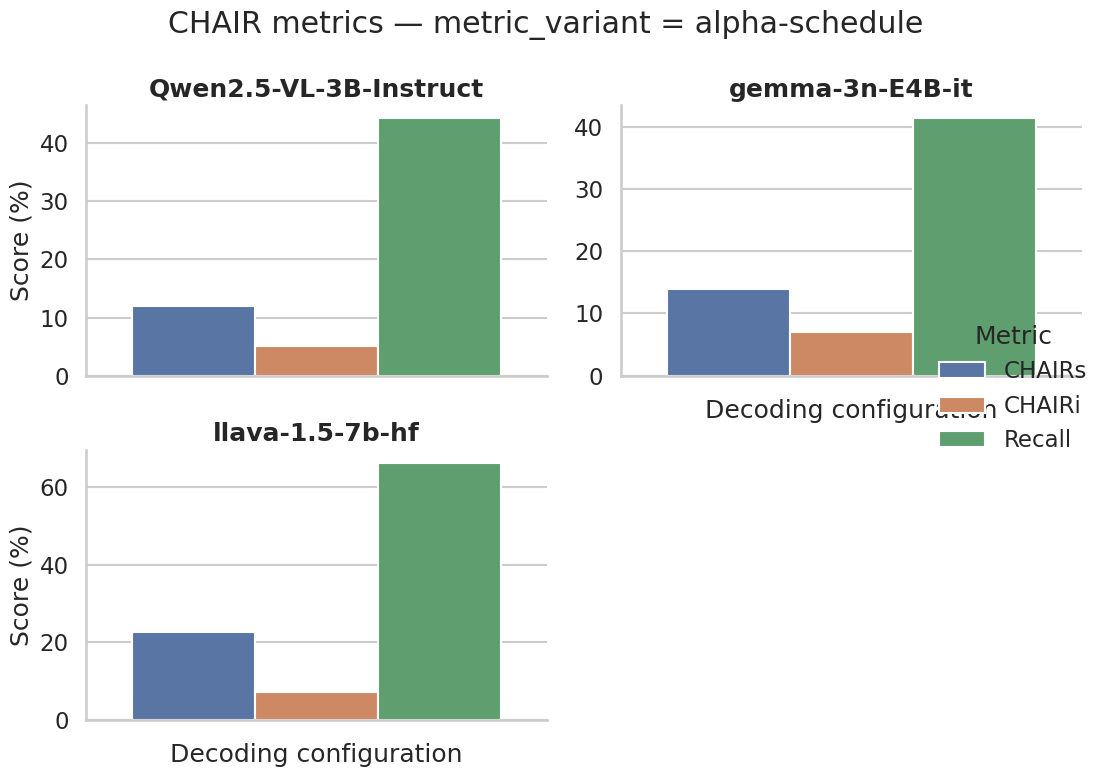

/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


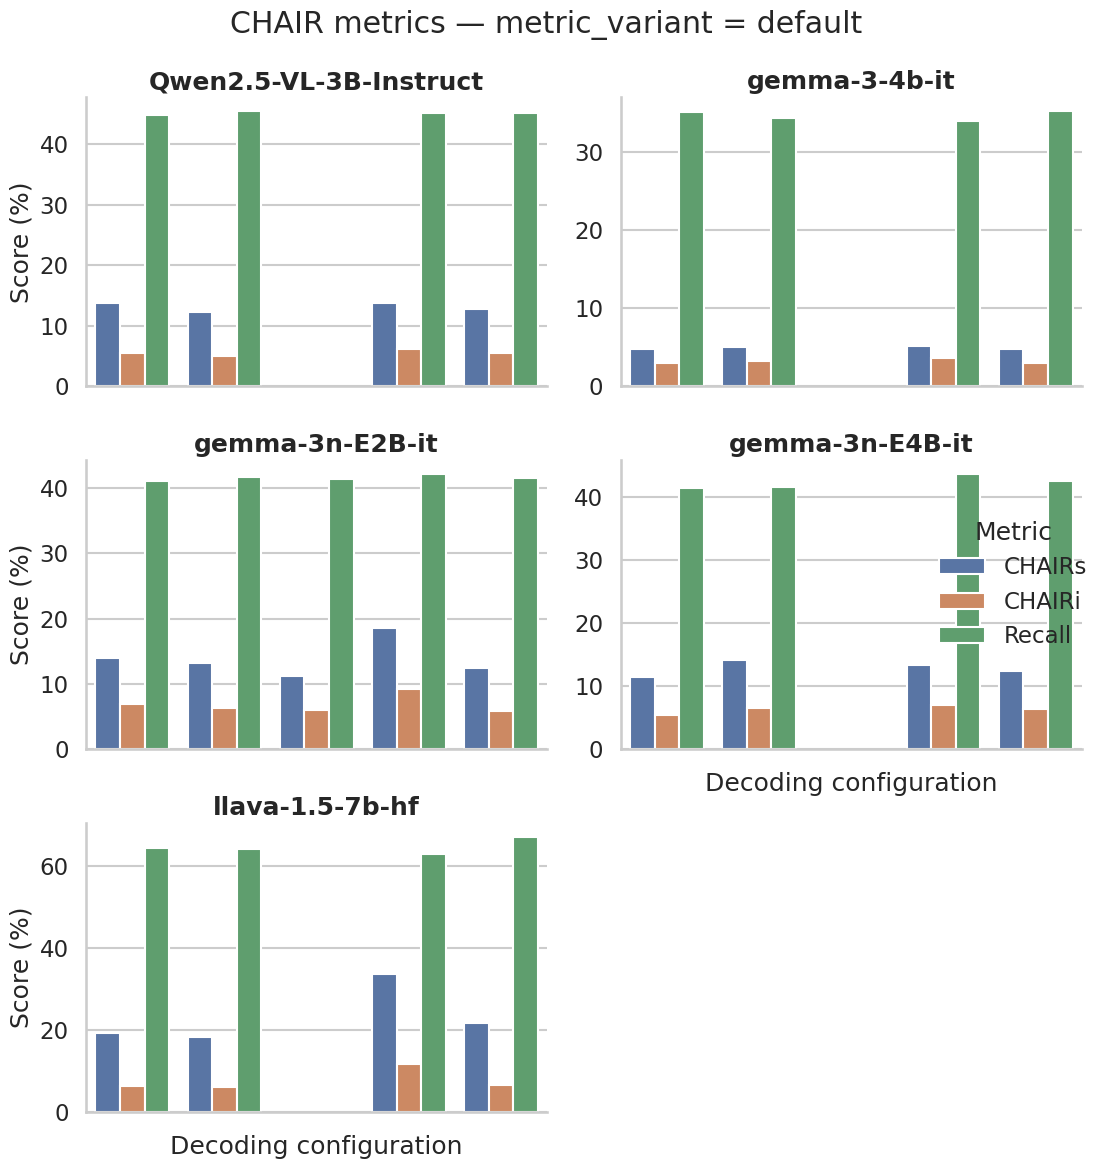

/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/home/DTC/tmp/ipykernel_1377572/2961963731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


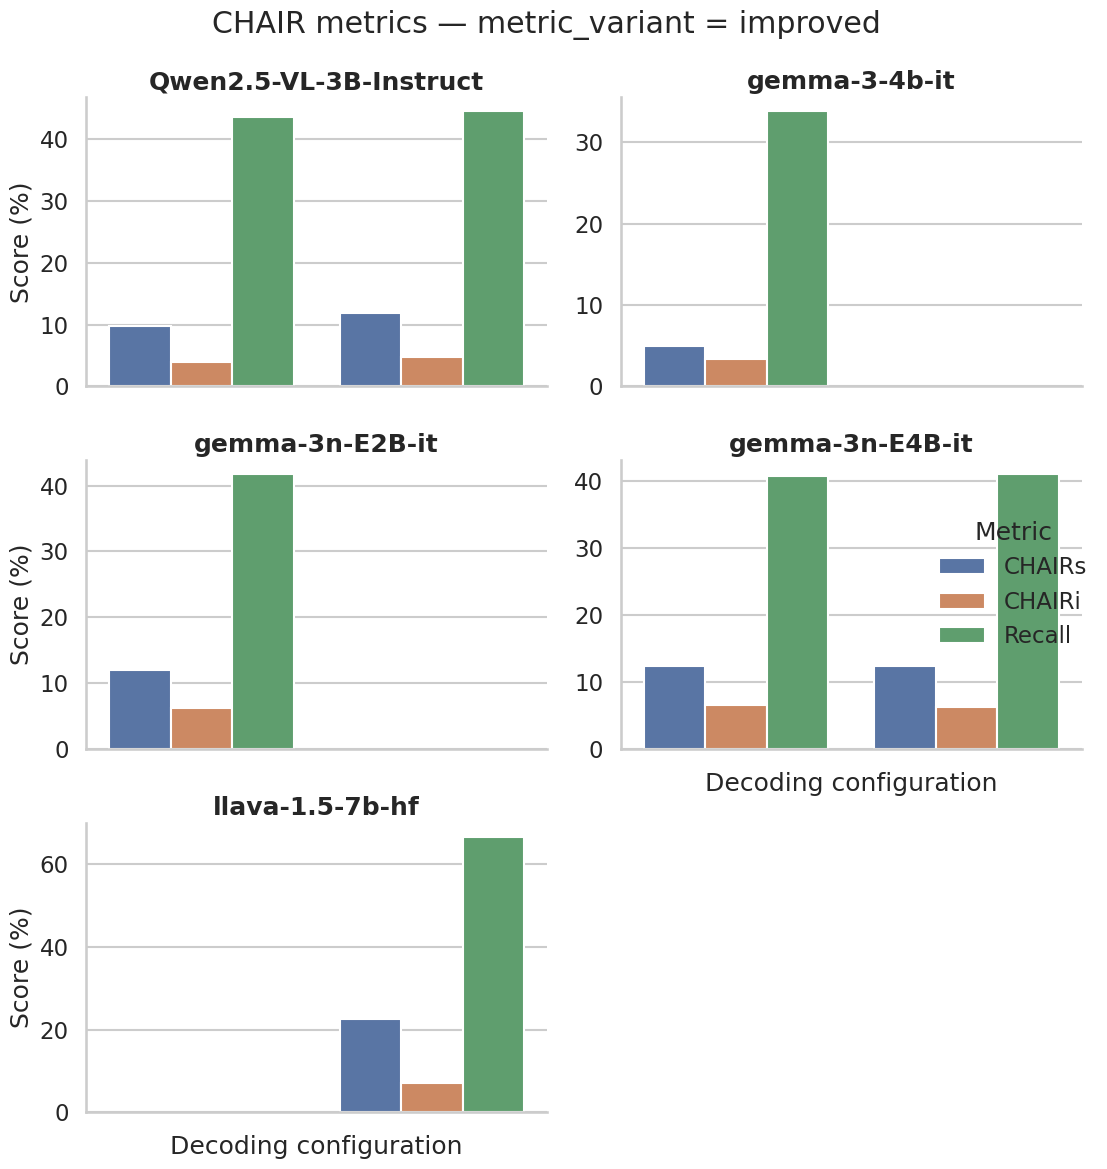

In [7]:
for metric_variant, subset in chair_df.groupby("metric_variant"):
    chair_long = subset.melt(
        id_vars=["provider", "model", "decoding"],
        value_vars=["CHAIRs", "CHAIRi", "Recall"],
        var_name="metric",
        value_name="score",
    )

    order = sorted(subset["decoding"].unique(), key=str.lower)
    g = sns.catplot(
        data=chair_long,
        kind="bar",
        x="decoding",
        y="score",
        hue="metric",
        col="model",
        col_wrap=2,
        order=order,
        height=4,
        aspect=1.2,
        sharey=False,
    )
    g.set_axis_labels("Decoding configuration", "Score (%)")
    g.set_titles("{col_name}")
    if g._legend is not None:
        g._legend.set_title("Metric")
    for ax in g.axes.flatten():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"CHAIR metrics — metric_variant = {metric_variant}")
    plt.tight_layout()
    plt.show()


In [8]:
pope_table = (
    pope_df
    .sort_values(["metric_variant", "provider", "model", "pope_type", "method", "variant"])
    [[
        "metric_variant",
        "provider",
        "model",
        "pope_type",
        "method",
        "variant",
        "accuracy",
        "f1_weighted",
        "precision_weighted",
        "recall_weighted",
    ]]
)


def display_pope_tables(df: pd.DataFrame):
    for metric_variant, subset in df.groupby("metric_variant"):
        styled = (
            subset.drop(columns="metric_variant")
            .reset_index(drop=True)
            .style
            .format({
                "accuracy": "{:.1f}%",
                "f1_weighted": "{:.1f}%",
                "precision_weighted": "{:.1f}%",
                "recall_weighted": "{:.1f}%",
            })
            .set_caption(f"Table 2.{metric_variant}: POPE metrics — metric_variant = {metric_variant}")
        )
        display(styled)


display_pope_tables(pope_table)


,provider,model,pope_type,method,variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,greedy,baseline,83.1%,83.0%,83.6%,83.1%
1,Qwen,Qwen2.5-VL-3B-Instruct,popular,greedy,baseline,87.3%,87.3%,87.3%,87.3%
2,Qwen,Qwen2.5-VL-3B-Instruct,random,beam,baseline,92.1%,92.1%,92.2%,92.1%
3,Qwen,Qwen2.5-VL-3B-Instruct,random,greedy,baseline,92.0%,92.0%,92.2%,92.0%
4,google,gemma-3-4b-it,adversarial,beam,baseline,79.5%,79.4%,80.2%,79.5%
5,google,gemma-3-4b-it,adversarial,dola,10-layers,78.8%,78.6%,79.8%,78.8%
6,google,gemma-3-4b-it,adversarial,greedy,baseline,79.4%,79.3%,80.2%,79.4%
7,google,gemma-3-4b-it,popular,beam,baseline,79.7%,79.6%,80.3%,79.7%
8,google,gemma-3-4b-it,popular,dola,10-layers,79.1%,78.9%,80.0%,79.1%
9,google,gemma-3-4b-it,popular,greedy,baseline,79.8%,79.7%,80.4%,79.8%


,provider,model,pope_type,method,variant,accuracy,f1_weighted,precision_weighted,recall_weighted
0,Qwen,Qwen2.5-VL-3B-Instruct,adversarial,deco,10-layers,83.7%,83.7%,84.2%,83.7%
1,Qwen,Qwen2.5-VL-3B-Instruct,popular,deco,10-layers,87.6%,87.6%,87.7%,87.6%
2,Qwen,Qwen2.5-VL-3B-Instruct,random,deco,10-layers,92.2%,92.2%,92.4%,92.2%
3,google,gemma-3-4b-it,adversarial,deco,10-layers,79.4%,79.3%,80.2%,79.4%
4,google,gemma-3-4b-it,popular,deco,10-layers,79.8%,79.7%,80.4%,79.8%
5,google,gemma-3-4b-it,random,deco,10-layers,84.5%,84.5%,84.6%,84.5%
6,google,gemma-3n-E2B-it,adversarial,deco,10-layers,82.6%,82.6%,82.9%,82.6%
7,google,gemma-3n-E2B-it,popular,deco,10-layers,83.7%,83.7%,83.9%,83.7%
8,google,gemma-3n-E2B-it,random,deco,10-layers,87.0%,87.0%,87.0%,87.0%
9,google,gemma-3n-E4B-it,adversarial,deco,10-layers,83.0%,83.0%,83.1%,83.0%


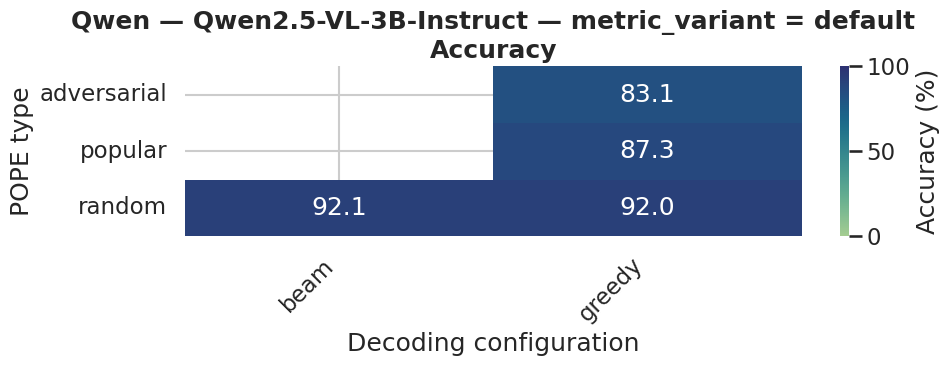

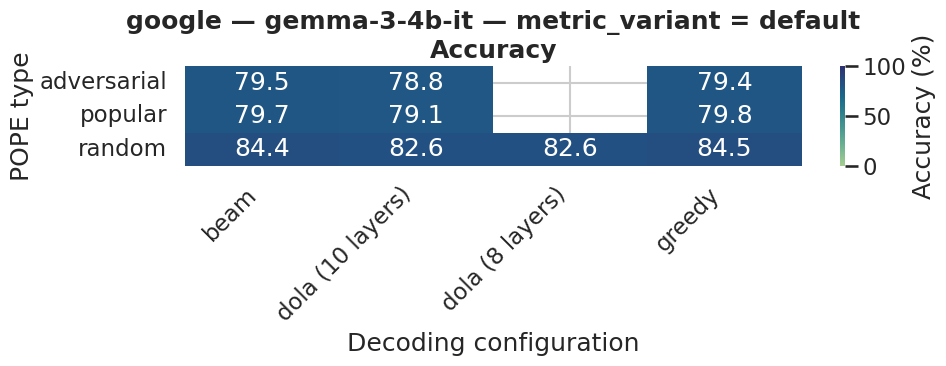

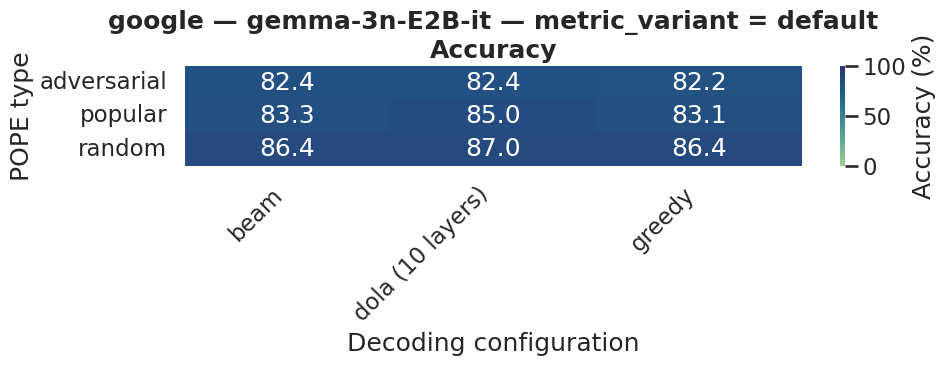

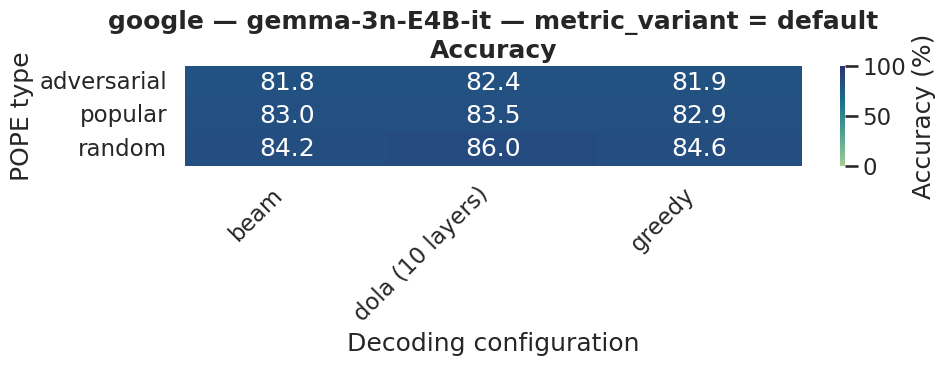

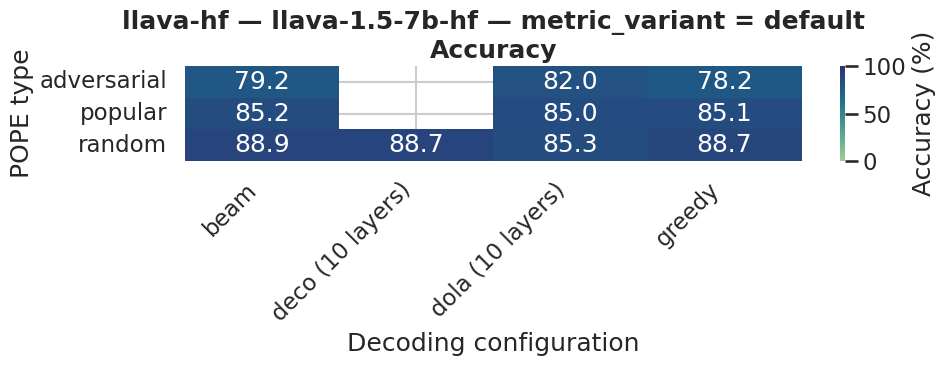

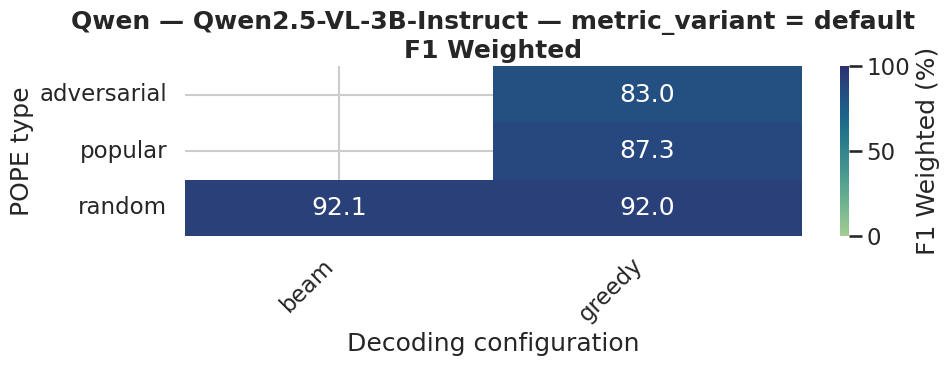

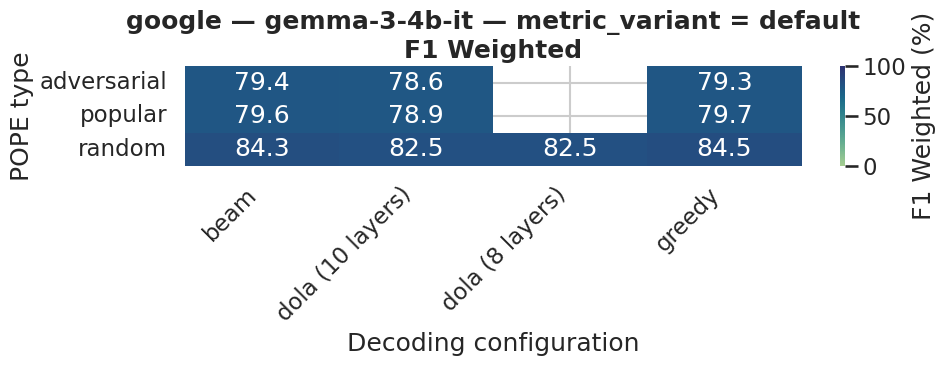

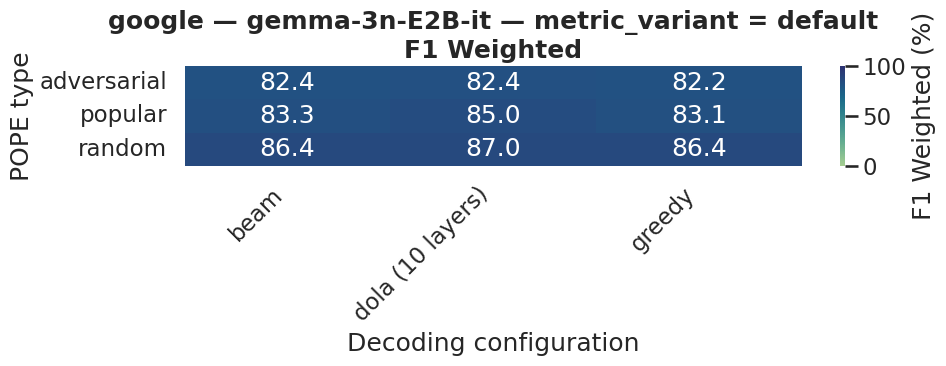

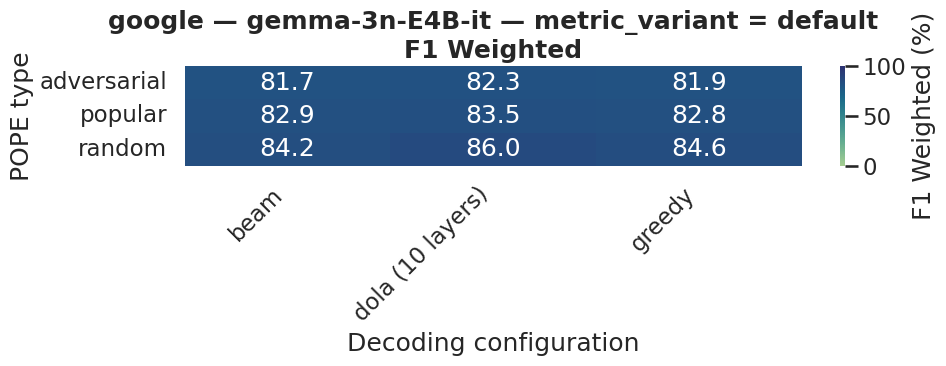

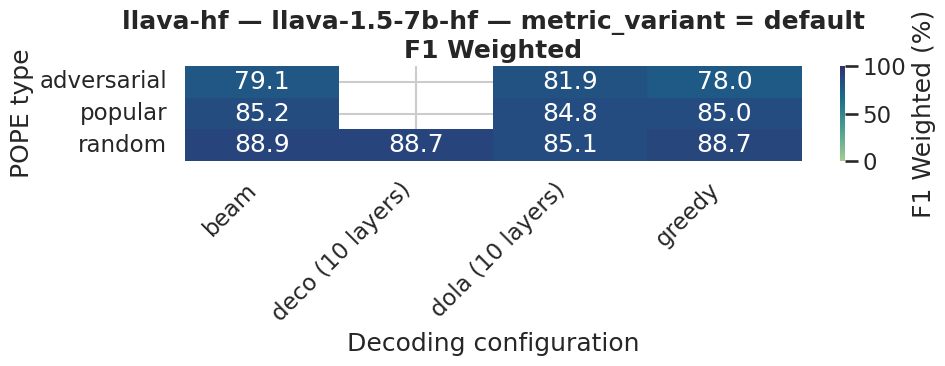

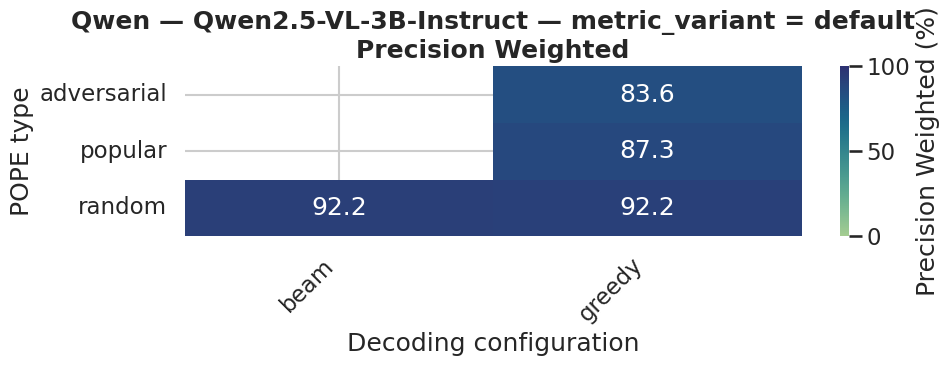

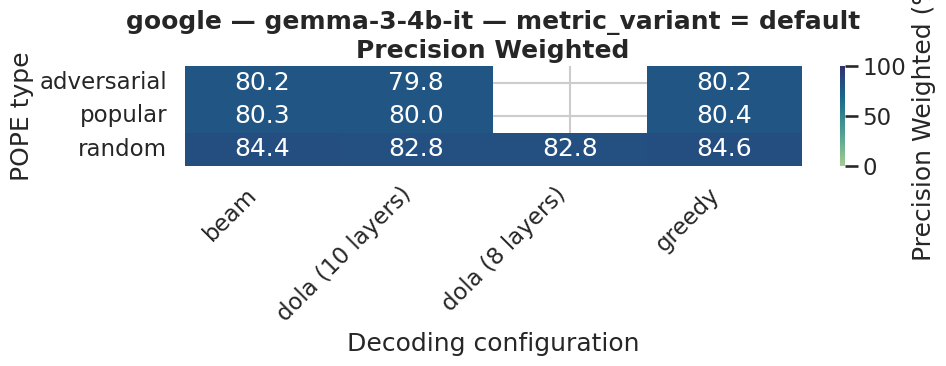

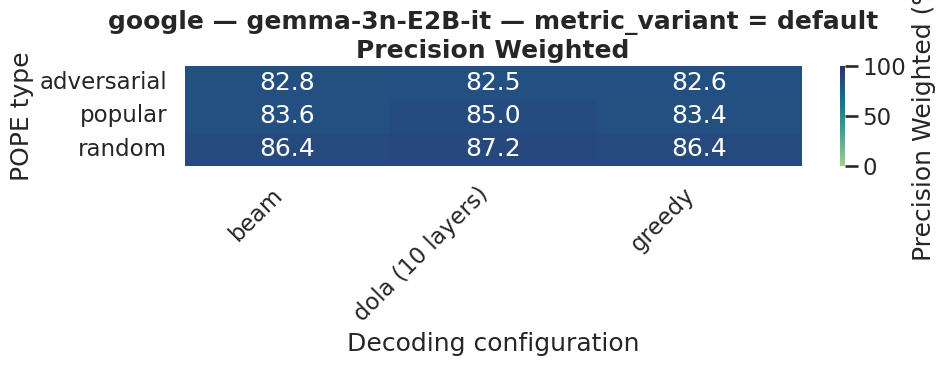

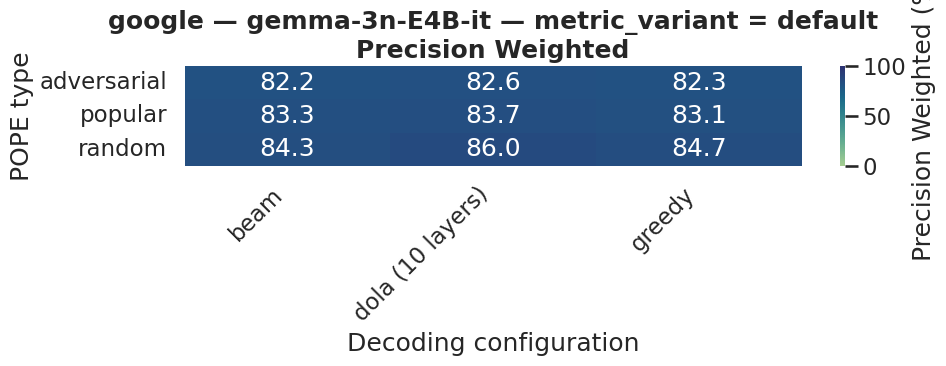

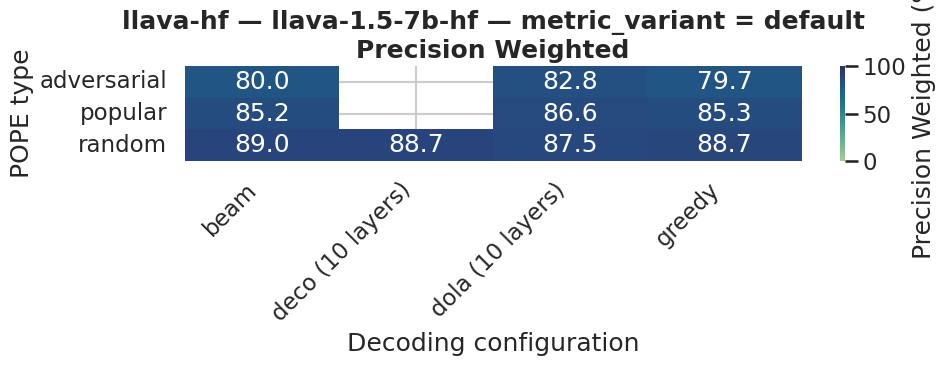

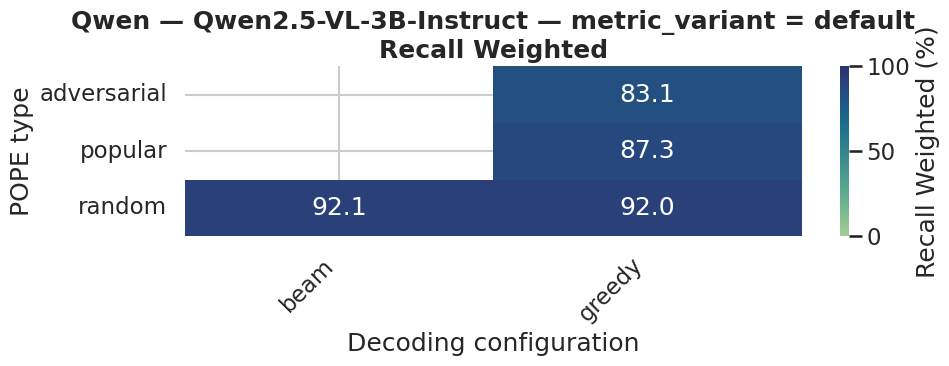

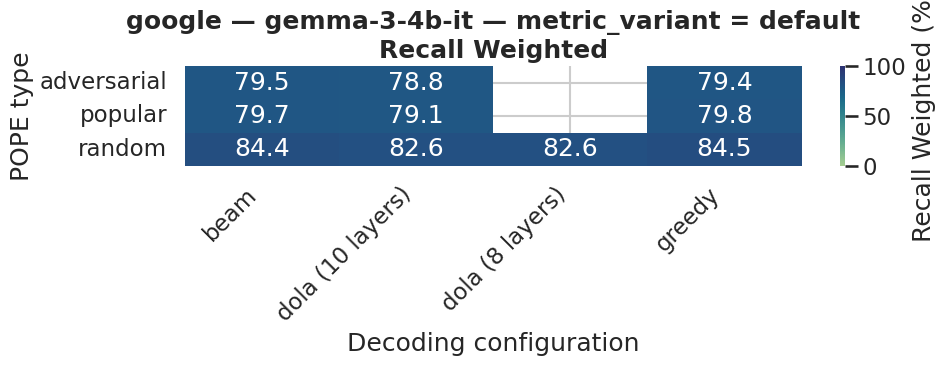

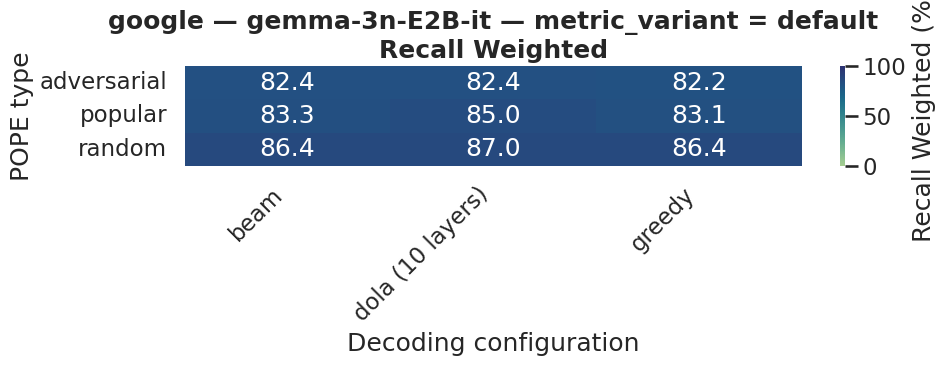

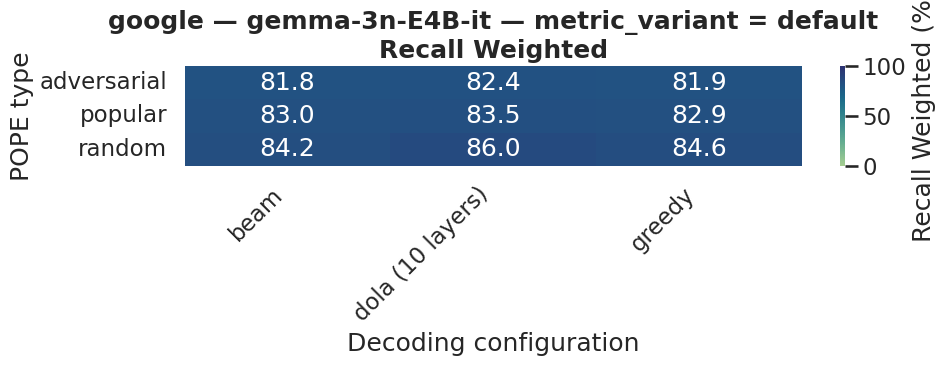

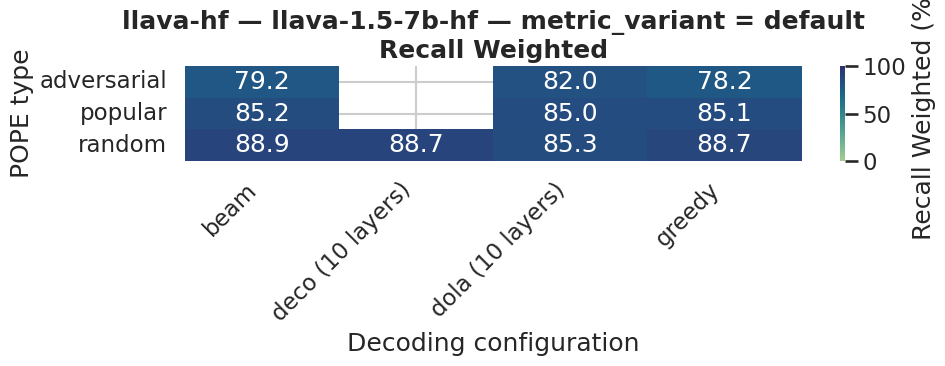

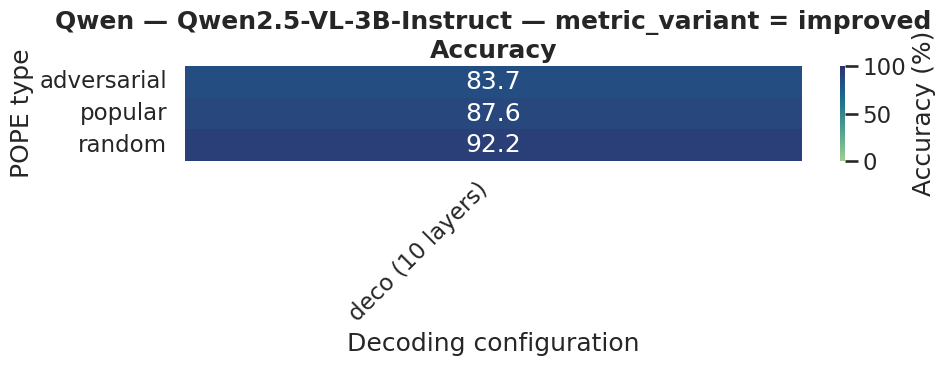

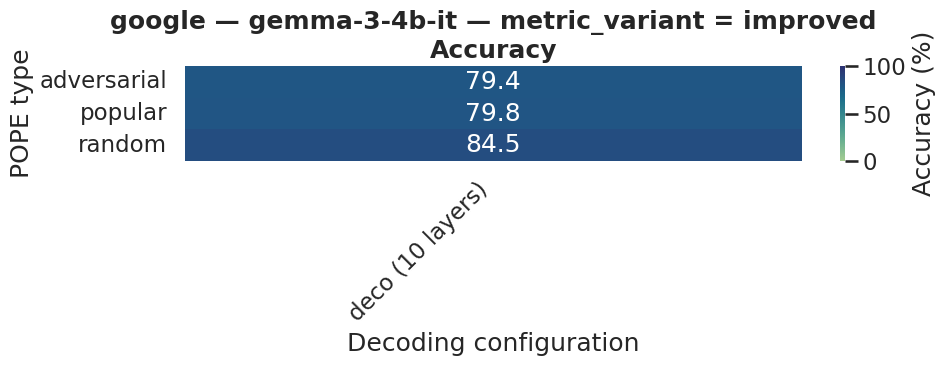

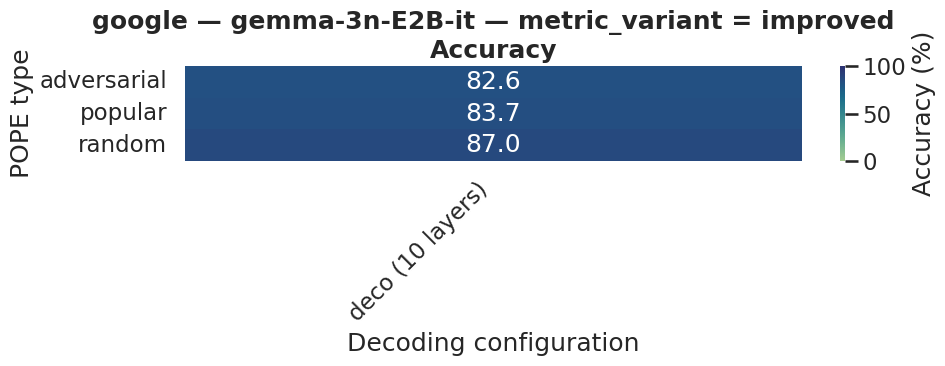

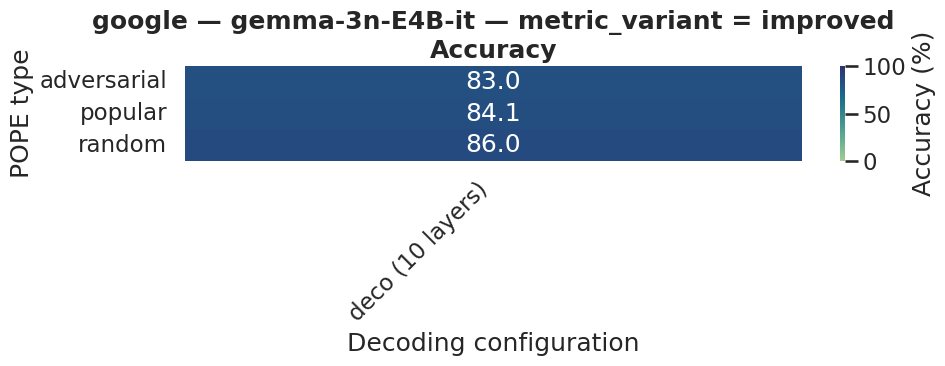

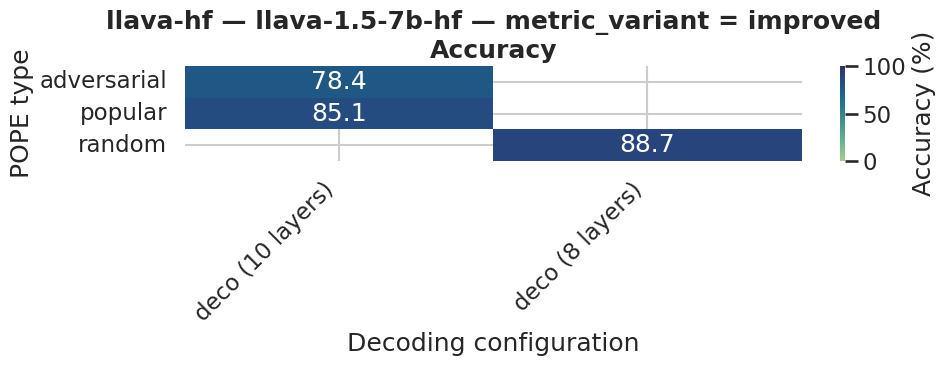

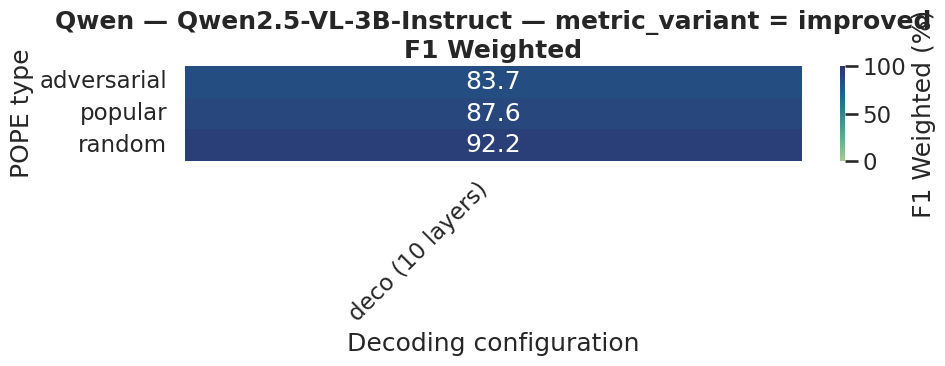

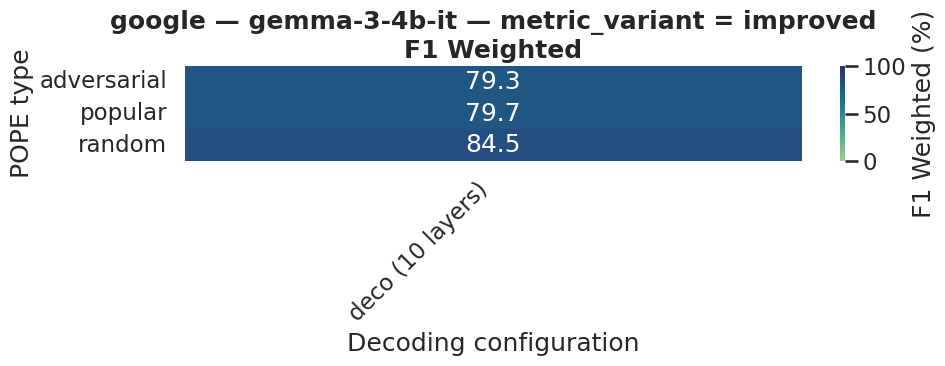

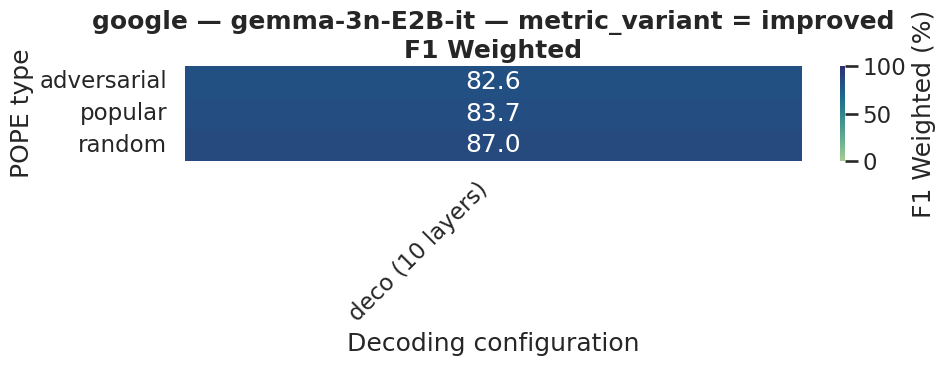

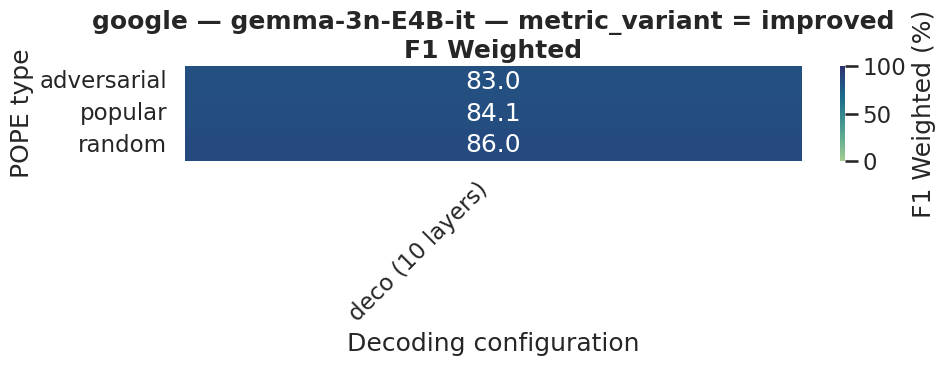

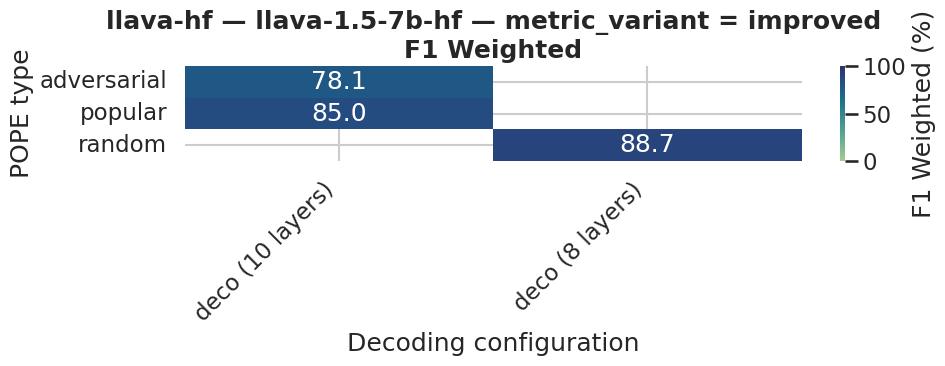

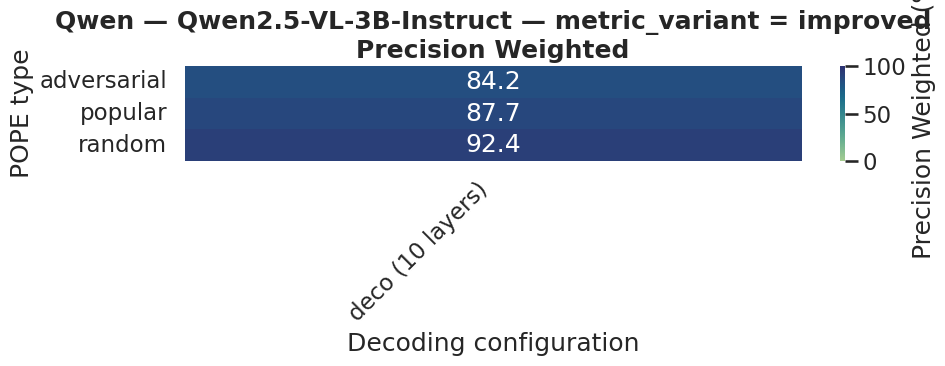

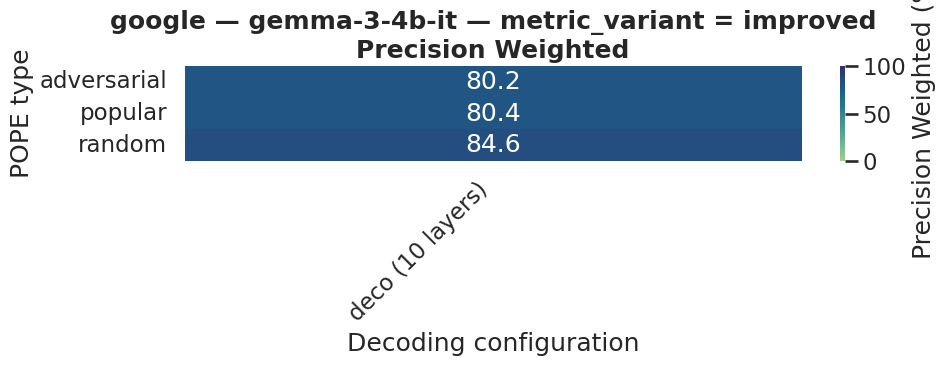

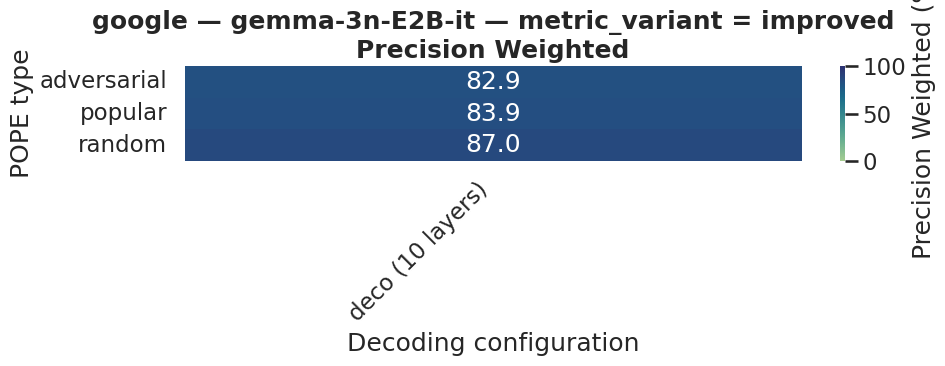

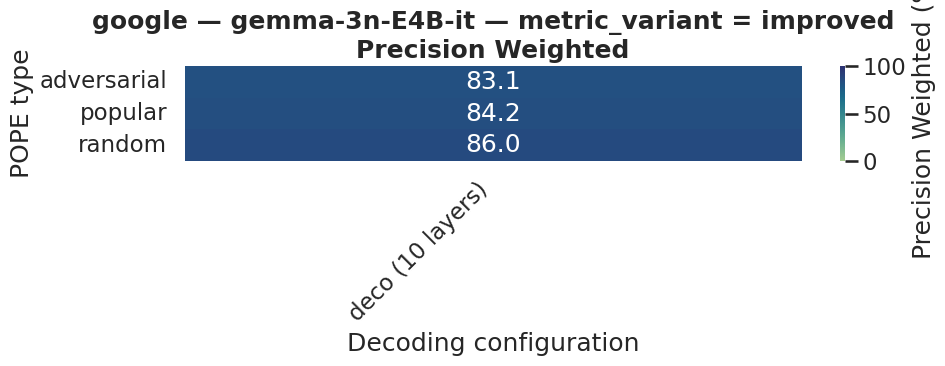

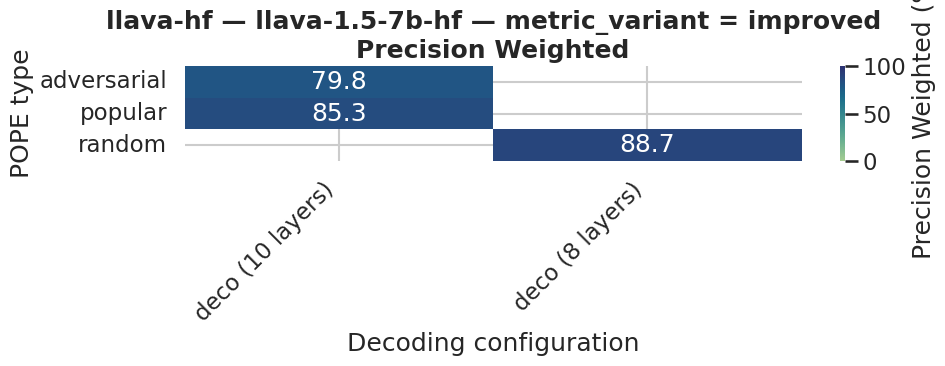

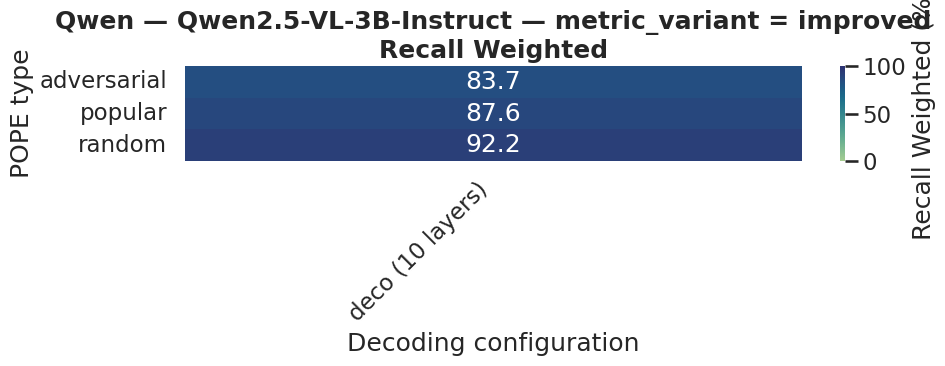

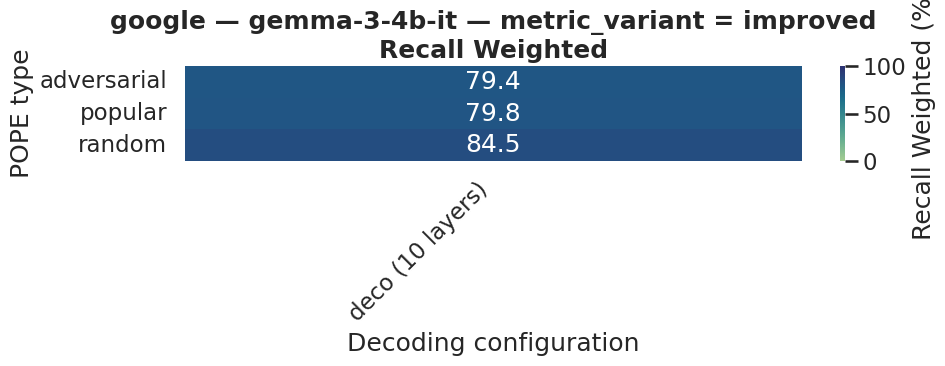

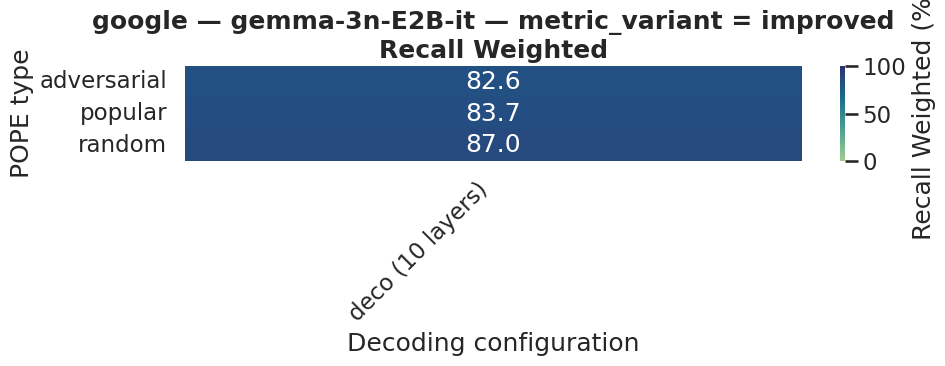

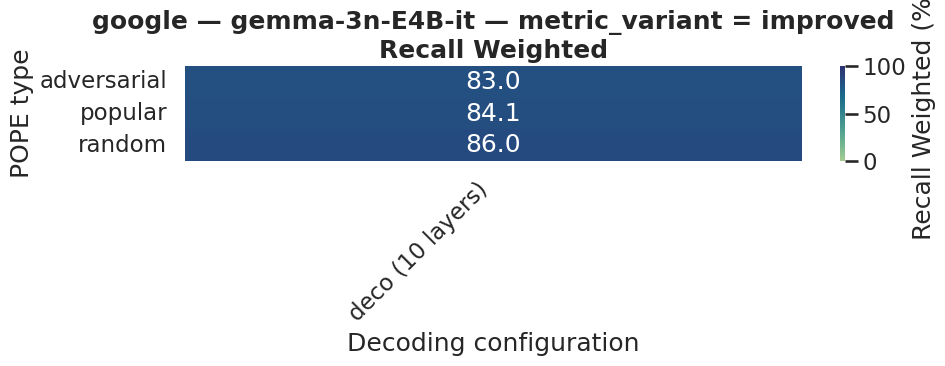

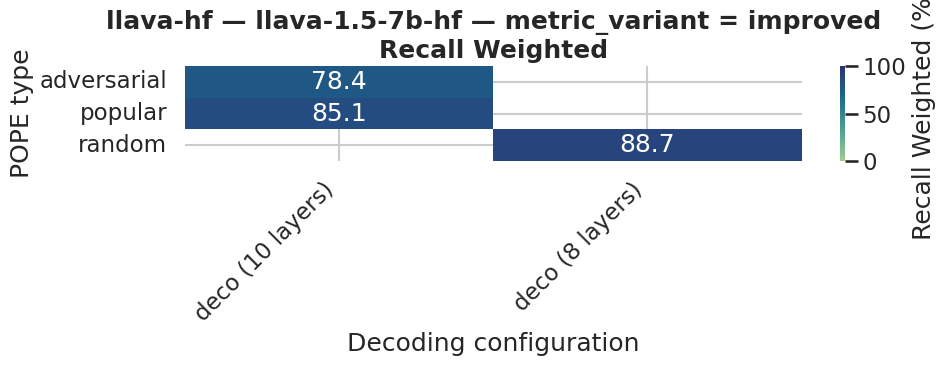

In [9]:
pope_metrics = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

for metric_variant, subset_variant in pope_df.groupby("metric_variant"):
    for metric_name in pope_metrics:
        for (provider, model), subset in subset_variant.groupby(["provider", "model"]):
            pivot = subset.pivot(index="pope_type", columns="decoding", values=metric_name)
            pivot = pivot.loc[sorted(pivot.index)]
            pivot = pivot[sorted(pivot.columns, key=str.lower)]
            plt.figure(figsize=(10, 4))
            sns.heatmap(
                pivot,
                annot=True,
                fmt=".1f",
                cmap="crest",
                vmin=0.0,
                vmax=100.0,
                cbar_kws={"label": metric_name.replace('_', ' ').title() + " (%)"},
            )
            # keep the title on a single f-string line (use \n for a line break)
            plt.title(
                f"{provider} — {model} — metric_variant = {metric_variant}\n"
                f"{metric_name.replace('_', ' ').title()}"
            )
            plt.xlabel("Decoding configuration")
            plt.ylabel("POPE type")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
